In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
import hdbscan
import pickle

I0000 00:00:1780201522.151966    7816 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780201522.210137    7816 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780201523.567694    7816 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

In [3]:

TAX_COLORS = {
    'S'    : '#ff4444',
    'C'    : '#4444ff',
    'X'    : '#ffaa00',
    'Other': '#44ff44',
}

COMPLEX_COLORS = {
    'S-complex': '#ff4444',
    'C-complex': '#4444ff',
    'X-complex': '#ffaa00',
    'V-type'   : '#ff00ff',
    'L-type'   : '#00ffff',
    'K-type'   : '#ffff00',
    'A-type'   : '#ff8800',
    'D-type'   : '#8800ff',
    'R-type'   : '#00ff88',
    'T-type'   : '#888888',
    'Other'    : '#ffffff',
}

In [4]:
core_path    = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)

unified_df     = pd.read_pickle(os.path.join(results_path, 'unified_df.pkl'))
spectra_matrix = np.load(os.path.join(results_path, 'spectra_matrix.npy'))
wavelengths    = np.load(os.path.join(results_path, 'wavelengths.npy'))

print(f"Dataset         : {len(unified_df):,}")
print(f"Spectra matrix  : {spectra_matrix.shape}")
print(f"\nClass distribution:")
print(unified_df['Main Group'].value_counts())

Dataset         : 1,181
Spectra matrix  : (1181, 49)

Class distribution:
Main Group
S        488
C        357
X        196
Other    140
Name: count, dtype: int64


In [5]:
SPECTRAL_FEATURES = ['slope_overall', 'slope_vis', 'slope_nir',
                     'depth_07um', 'depth_09um', 'curvature',
                     'ref_044', 'ref_070', 'ref_085', 'ref_092',
                     'ratio_nir_vis']

ORBITAL_FEATURES  = ['a_p', 'e_p', 'sin_i_p', 'g', 's', 'LCE', 'rms_a']

COMBINED_FEATURES = SPECTRAL_FEATURES + ORBITAL_FEATURES

feature_spaces = {
    'Spectral'          : SPECTRAL_FEATURES,
    'Orbital'           : ORBITAL_FEATURES,
    'Combined'          : COMBINED_FEATURES,
}

print("Feature spaces:")
for name, feats in feature_spaces.items():
    print(f"  {name:<15} : {len(feats)} features")

# Also prepare raw spectra matrix (49 wavelength points)
scaler_spec = RobustScaler()
X_raw_spec  = scaler_spec.fit_transform(spectra_matrix)
print(f"\n  Raw spectra    : {X_raw_spec.shape[1]} features")

Feature spaces:
  Spectral        : 11 features
  Orbital         : 7 features
  Combined        : 18 features

  Raw spectra    : 49 features


In [6]:
embeddings = {}

UMAP_PARAMS = dict(
    n_components  = 2,
    n_neighbors   = 20,
    min_dist      = 0.05,
    metric        = 'euclidean',
    random_state  = 42,
    verbose       = False
)

# Feature-based embeddings
for space_name, features in feature_spaces.items():
    print(f"Computing UMAP — {space_name}...")
    X      = unified_df[features].astype(float).values
    scaler = RobustScaler()
    X_s    = scaler.fit_transform(X)

    reducer    = umap.UMAP(**UMAP_PARAMS)
    embedding  = reducer.fit_transform(X_s)
    embeddings[space_name] = embedding
    print(f"  Done → shape {embedding.shape}")

# Raw spectra embedding
print("Computing UMAP — Raw Spectra (49 points)...")
reducer_raw   = umap.UMAP(**UMAP_PARAMS)
emb_raw_spec  = reducer_raw.fit_transform(X_raw_spec)
embeddings['Raw Spectra'] = emb_raw_spec
print(f"  Done → shape {emb_raw_spec.shape}")

# Store in unified_df for convenience
for space_name, emb in embeddings.items():
    col = space_name.lower().replace(' ', '_')
    unified_df[f'umap_{col}_x'] = emb[:, 0]
    unified_df[f'umap_{col}_y'] = emb[:, 1]

print("\nAll embeddings computed.")

Computing UMAP — Spectral...


/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done → shape (1181, 2)
Computing UMAP — Orbital...


/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done → shape (1181, 2)
Computing UMAP — Combined...


/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done → shape (1181, 2)
Computing UMAP — Raw Spectra (49 points)...


/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done → shape (1181, 2)

All embeddings computed.


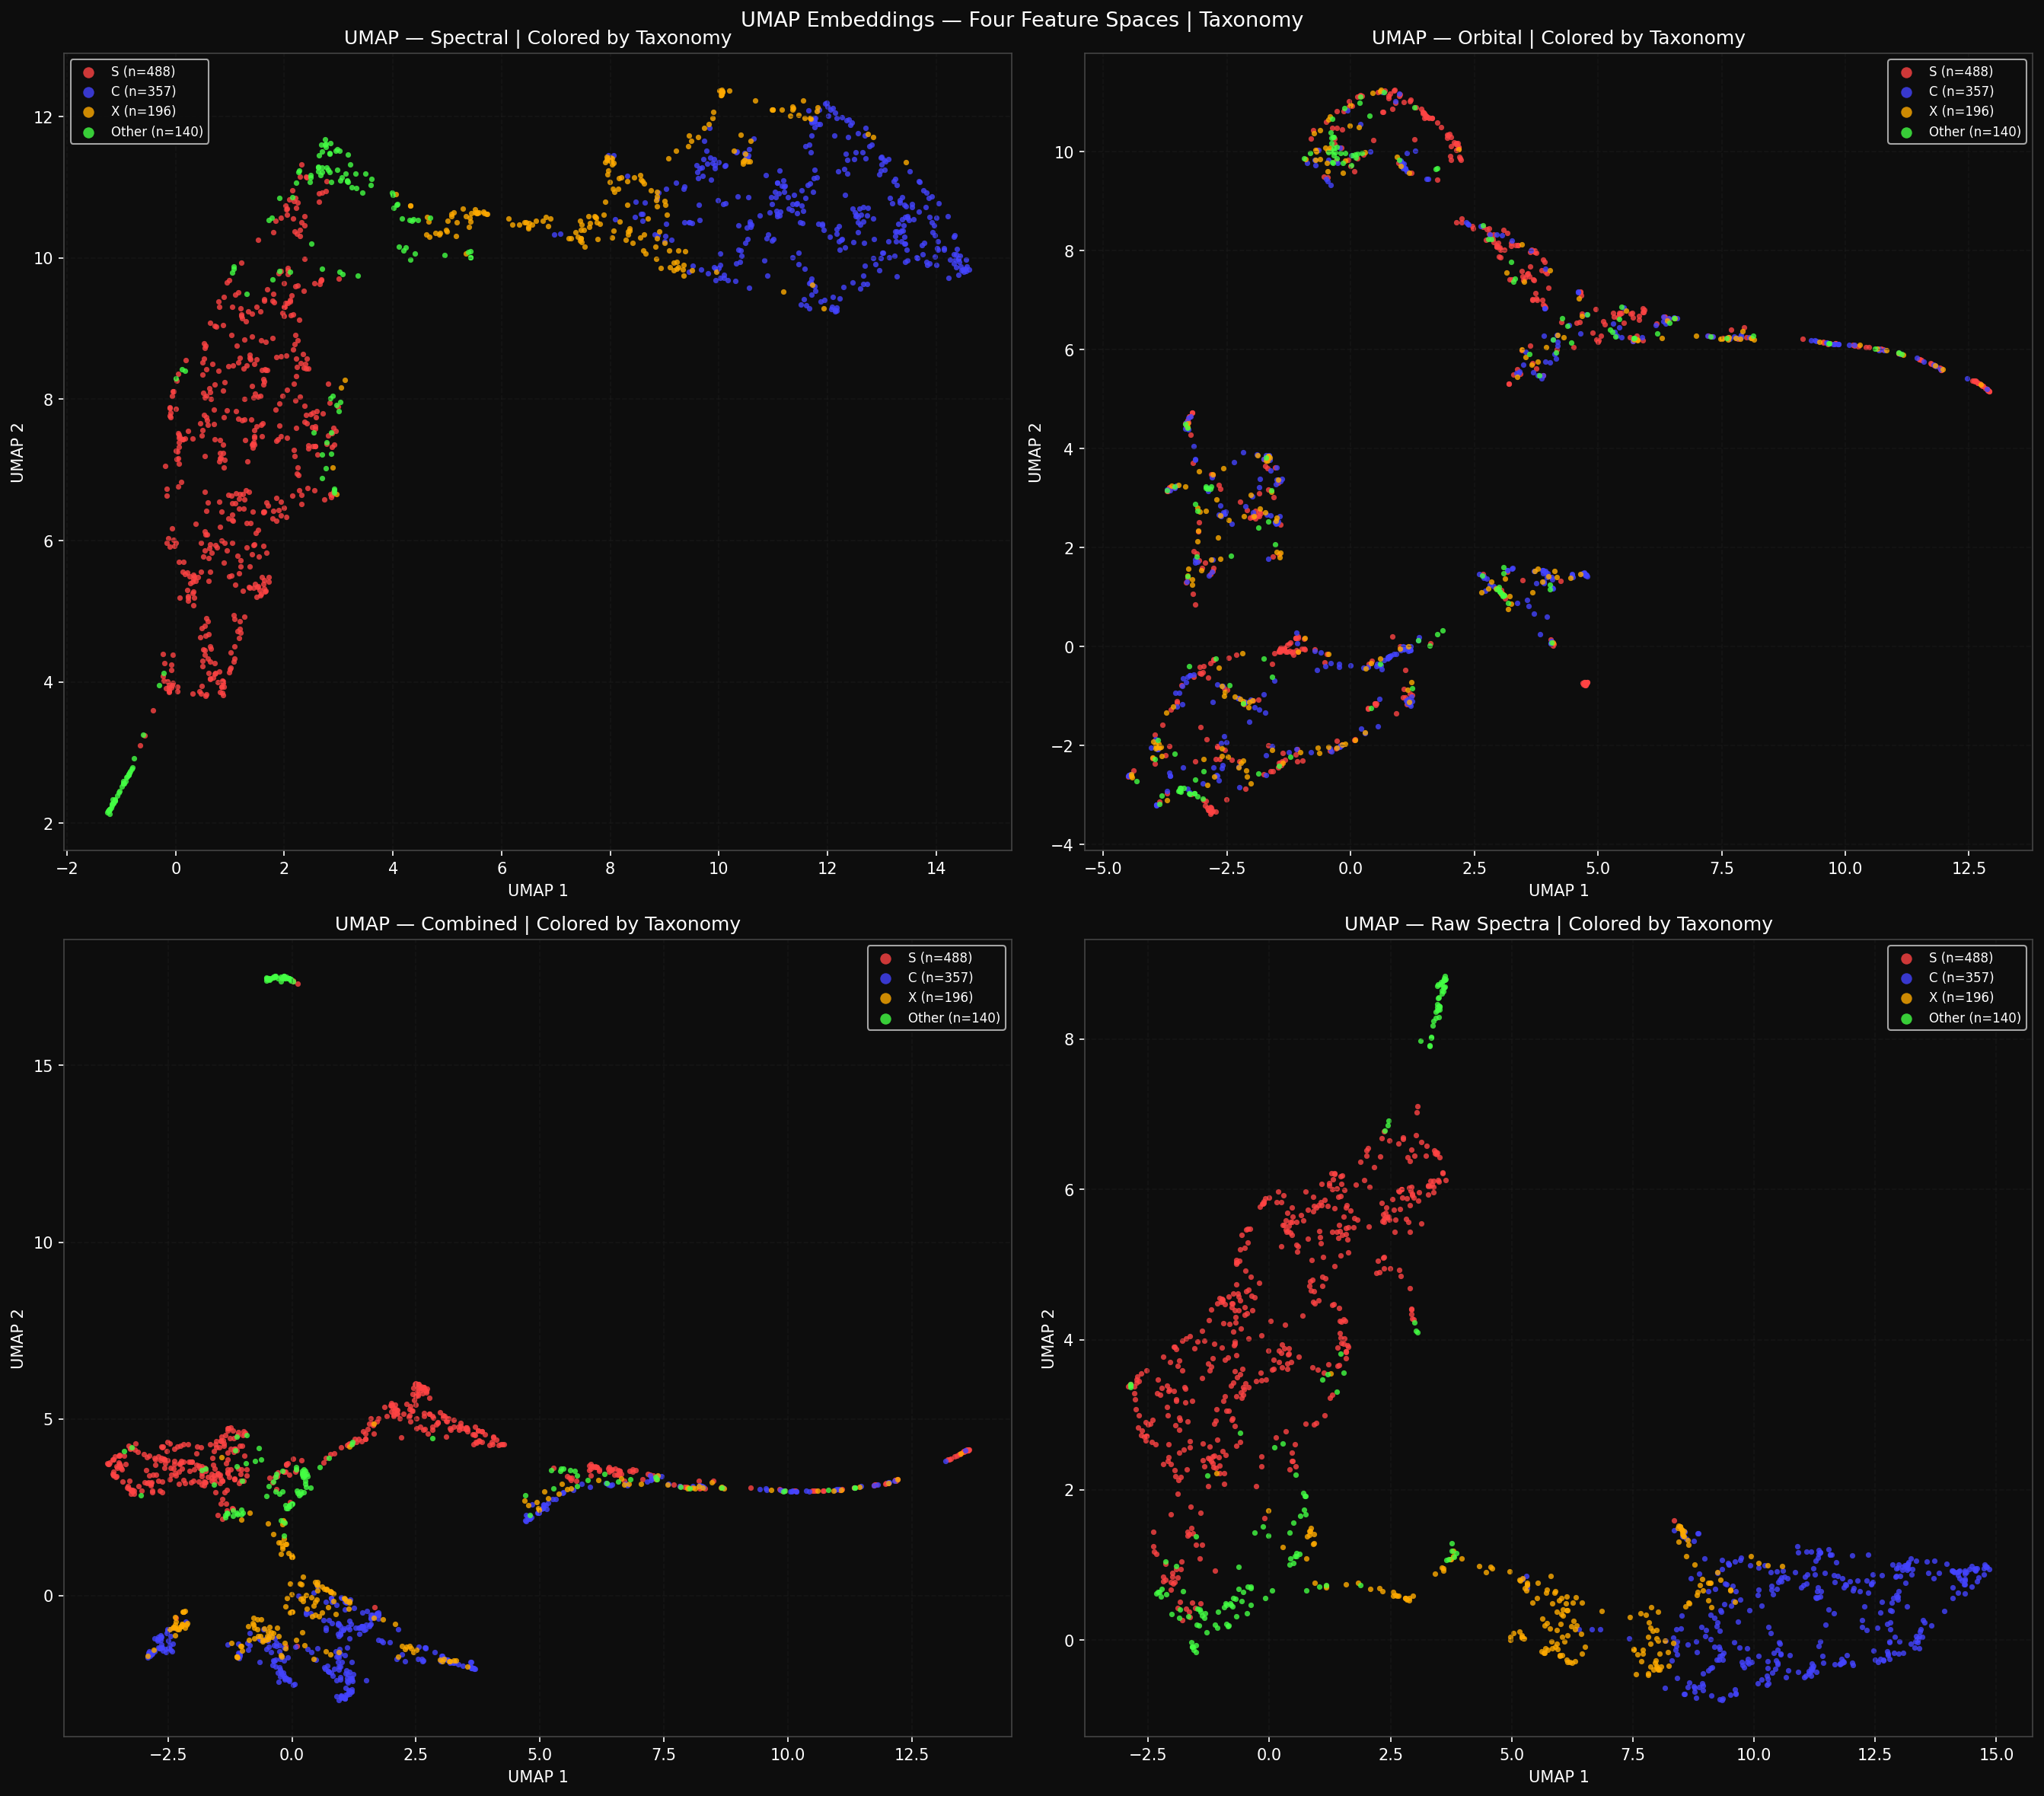

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

groups = ['S', 'C', 'X', 'Other']

for ax, (space_name, emb) in zip(axes, embeddings.items()):
    for group in groups:
        mask = unified_df['Main Group'] == group
        ax.scatter(
            emb[mask, 0], emb[mask, 1],
            s=12, c=TAX_COLORS[group], alpha=0.8,
            linewidths=0, label=f'{group} (n={mask.sum()})'
        )
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'UMAP — {space_name} | Colored by Taxonomy')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True)

plt.suptitle('UMAP Embeddings — Four Feature Spaces | Taxonomy',
             fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_umap_taxonomy.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

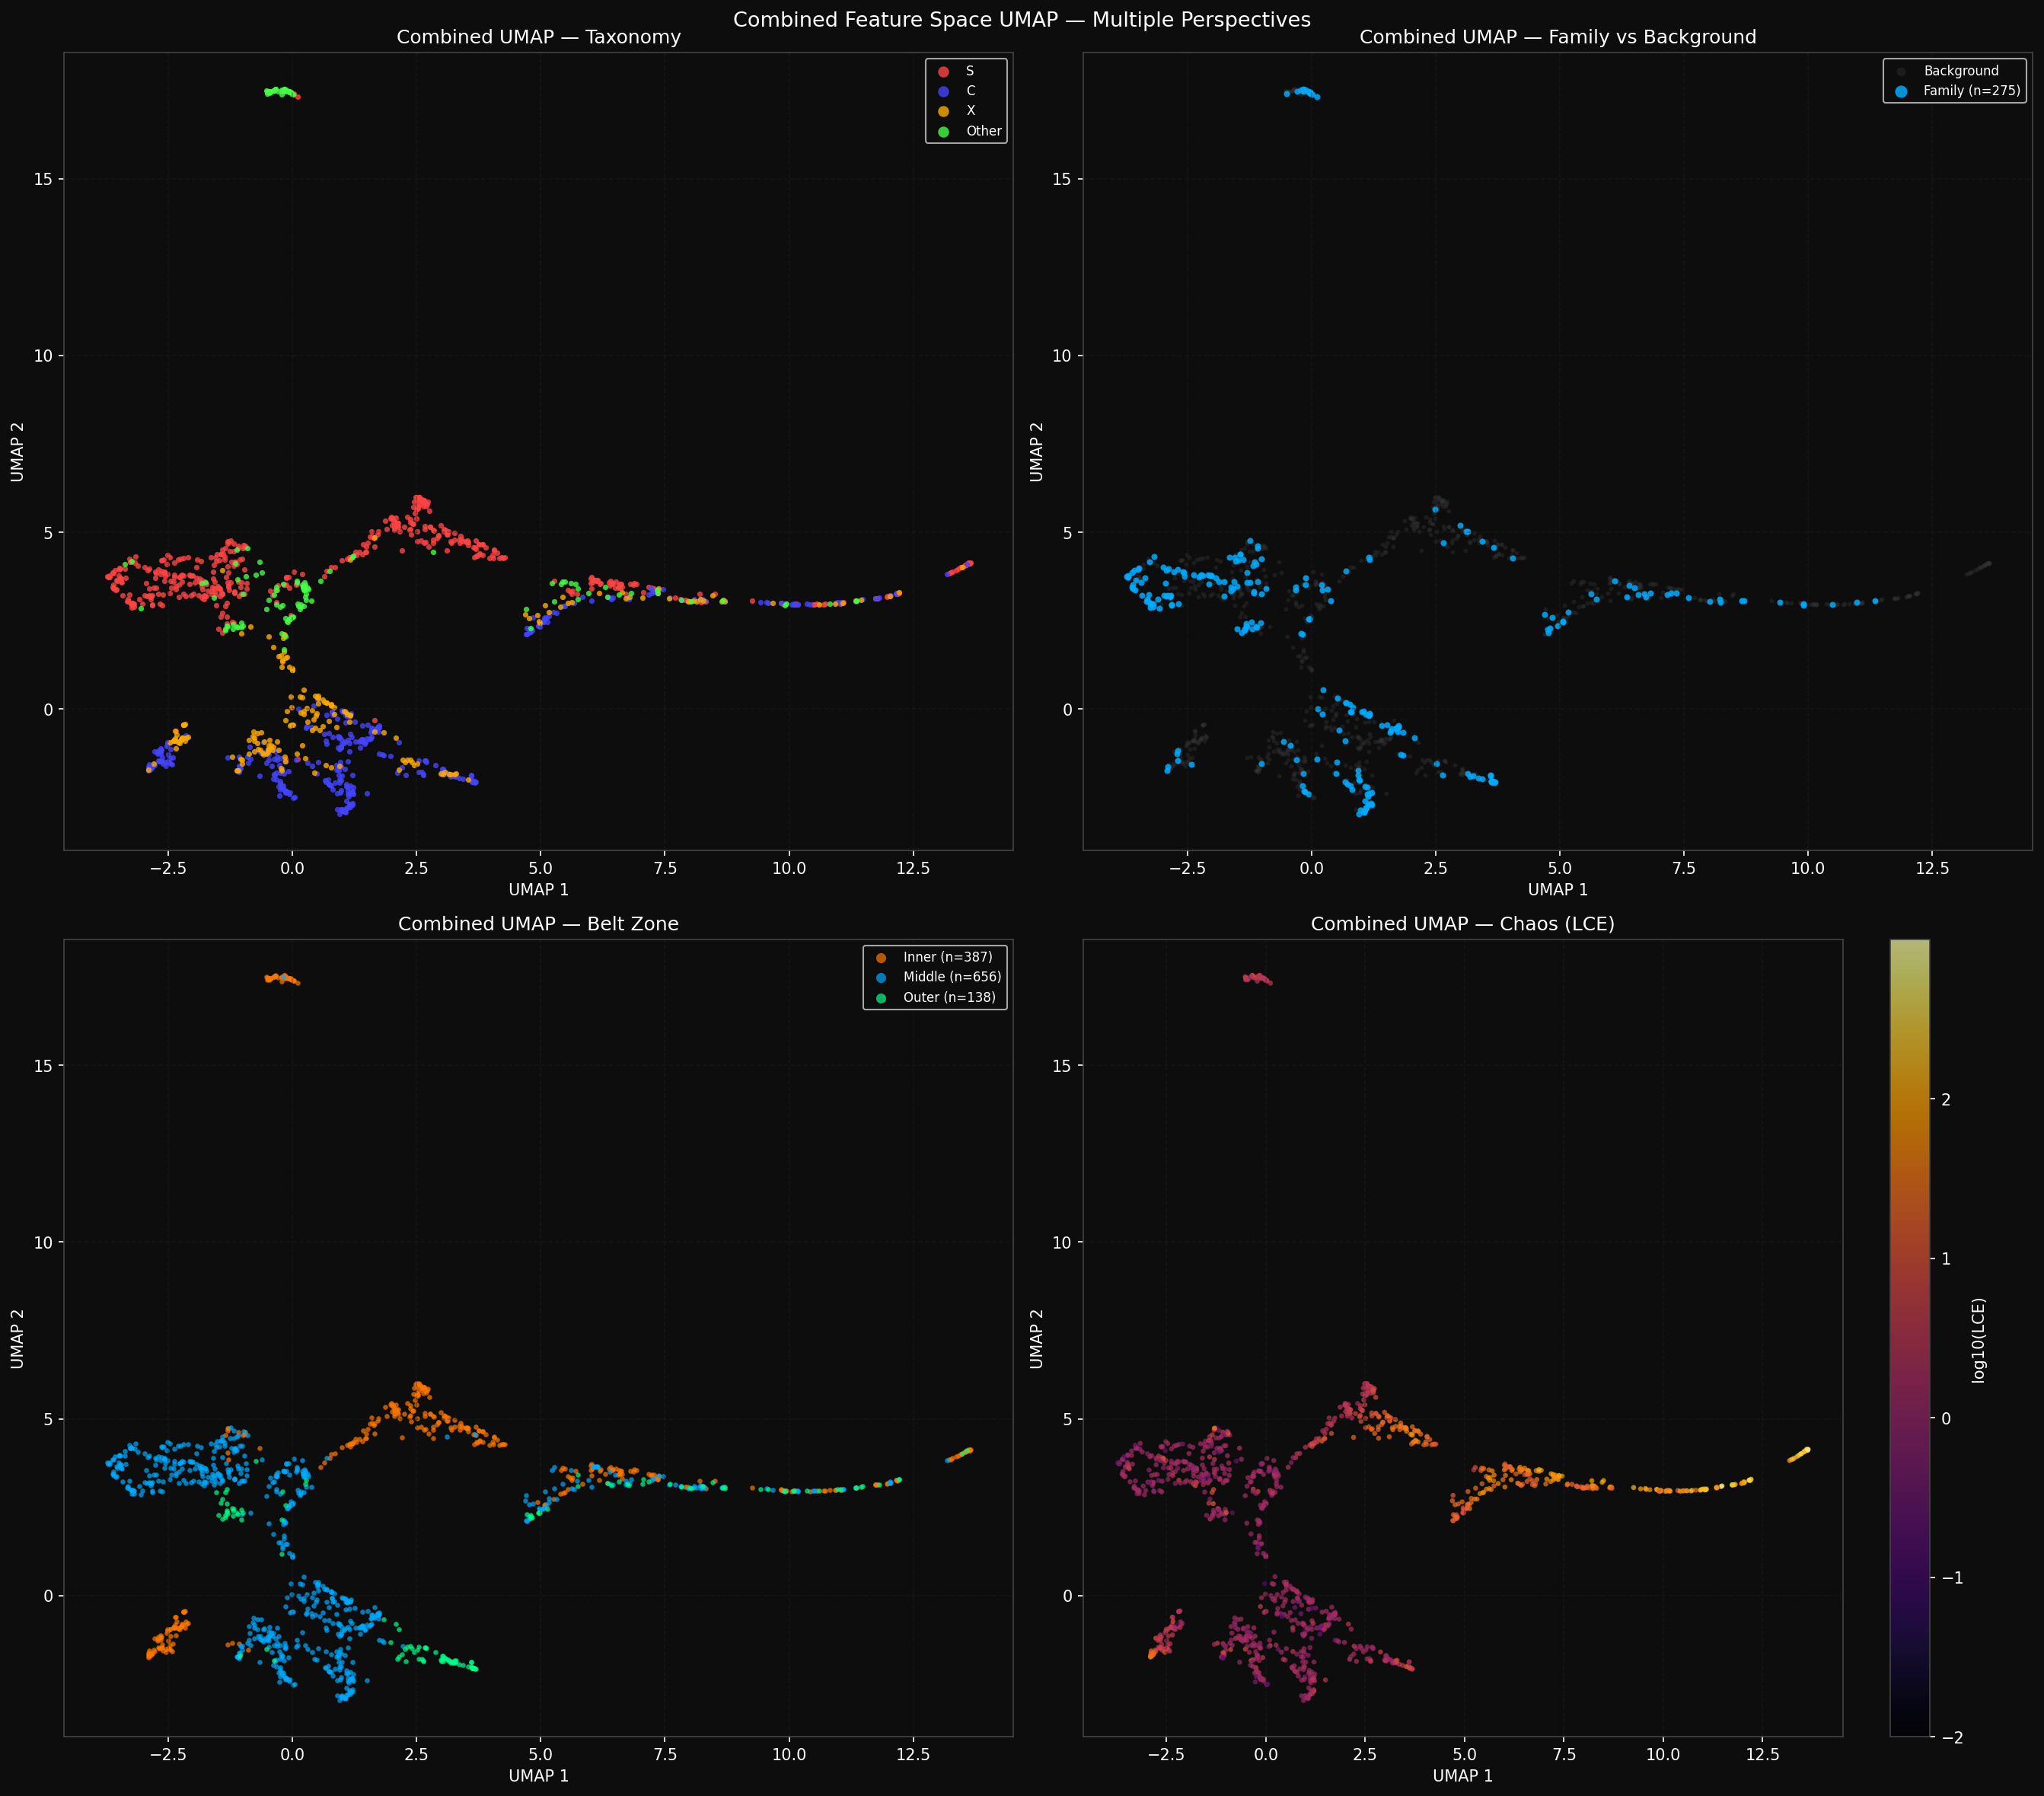

In [8]:
emb = embeddings['Combined']

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# 1. Color by taxonomy
ax = axes[0, 0]
for group in groups:
    mask = unified_df['Main Group'] == group
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=12, c=TAX_COLORS[group], alpha=0.8,
               linewidths=0, label=group)
ax.set_title('Combined UMAP — Taxonomy')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

# 2. Color by family membership
ax = axes[0, 1]
fam_mask = unified_df['is_family_member'].values
ax.scatter(emb[~fam_mask, 0], emb[~fam_mask, 1],
           s=8, c='#333333', alpha=0.4,
           linewidths=0, label='Background')
ax.scatter(emb[fam_mask, 0], emb[fam_mask, 1],
           s=15, c='#00aaff', alpha=0.85,
           linewidths=0, label=f'Family (n={fam_mask.sum()})')
ax.set_title('Combined UMAP — Family vs Background')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

# 3. Color by belt zone
ax = axes[1, 0]
zone_colors = {'Inner': '#ff7700', 'Middle': '#00aaff', 'Outer': '#00ff88'}
for zone, (a_min, a_max) in [
    ('Inner',  (2.0,  2.5)),
    ('Middle', (2.5,  2.95)),
    ('Outer',  (2.95, 3.5)),
]:
    mask = (unified_df['a_p'] >= a_min) & (unified_df['a_p'] < a_max)
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=10, c=zone_colors[zone], alpha=0.7,
               linewidths=0, label=f'{zone} (n={mask.sum()})')
ax.set_title('Combined UMAP — Belt Zone')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

# 4. Color by LCE (chaos)
ax = axes[1, 1]
sc = ax.scatter(emb[:, 0], emb[:, 1],
                s=10, c=np.log10(unified_df['LCE']),
                cmap='inferno', alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label='log10(LCE)')
ax.set_title('Combined UMAP — Chaos (LCE)')
ax.grid(True)

for ax in axes.flatten():
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.suptitle('Combined Feature Space UMAP — Multiple Perspectives',
             fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_umap_combined_multipanel.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

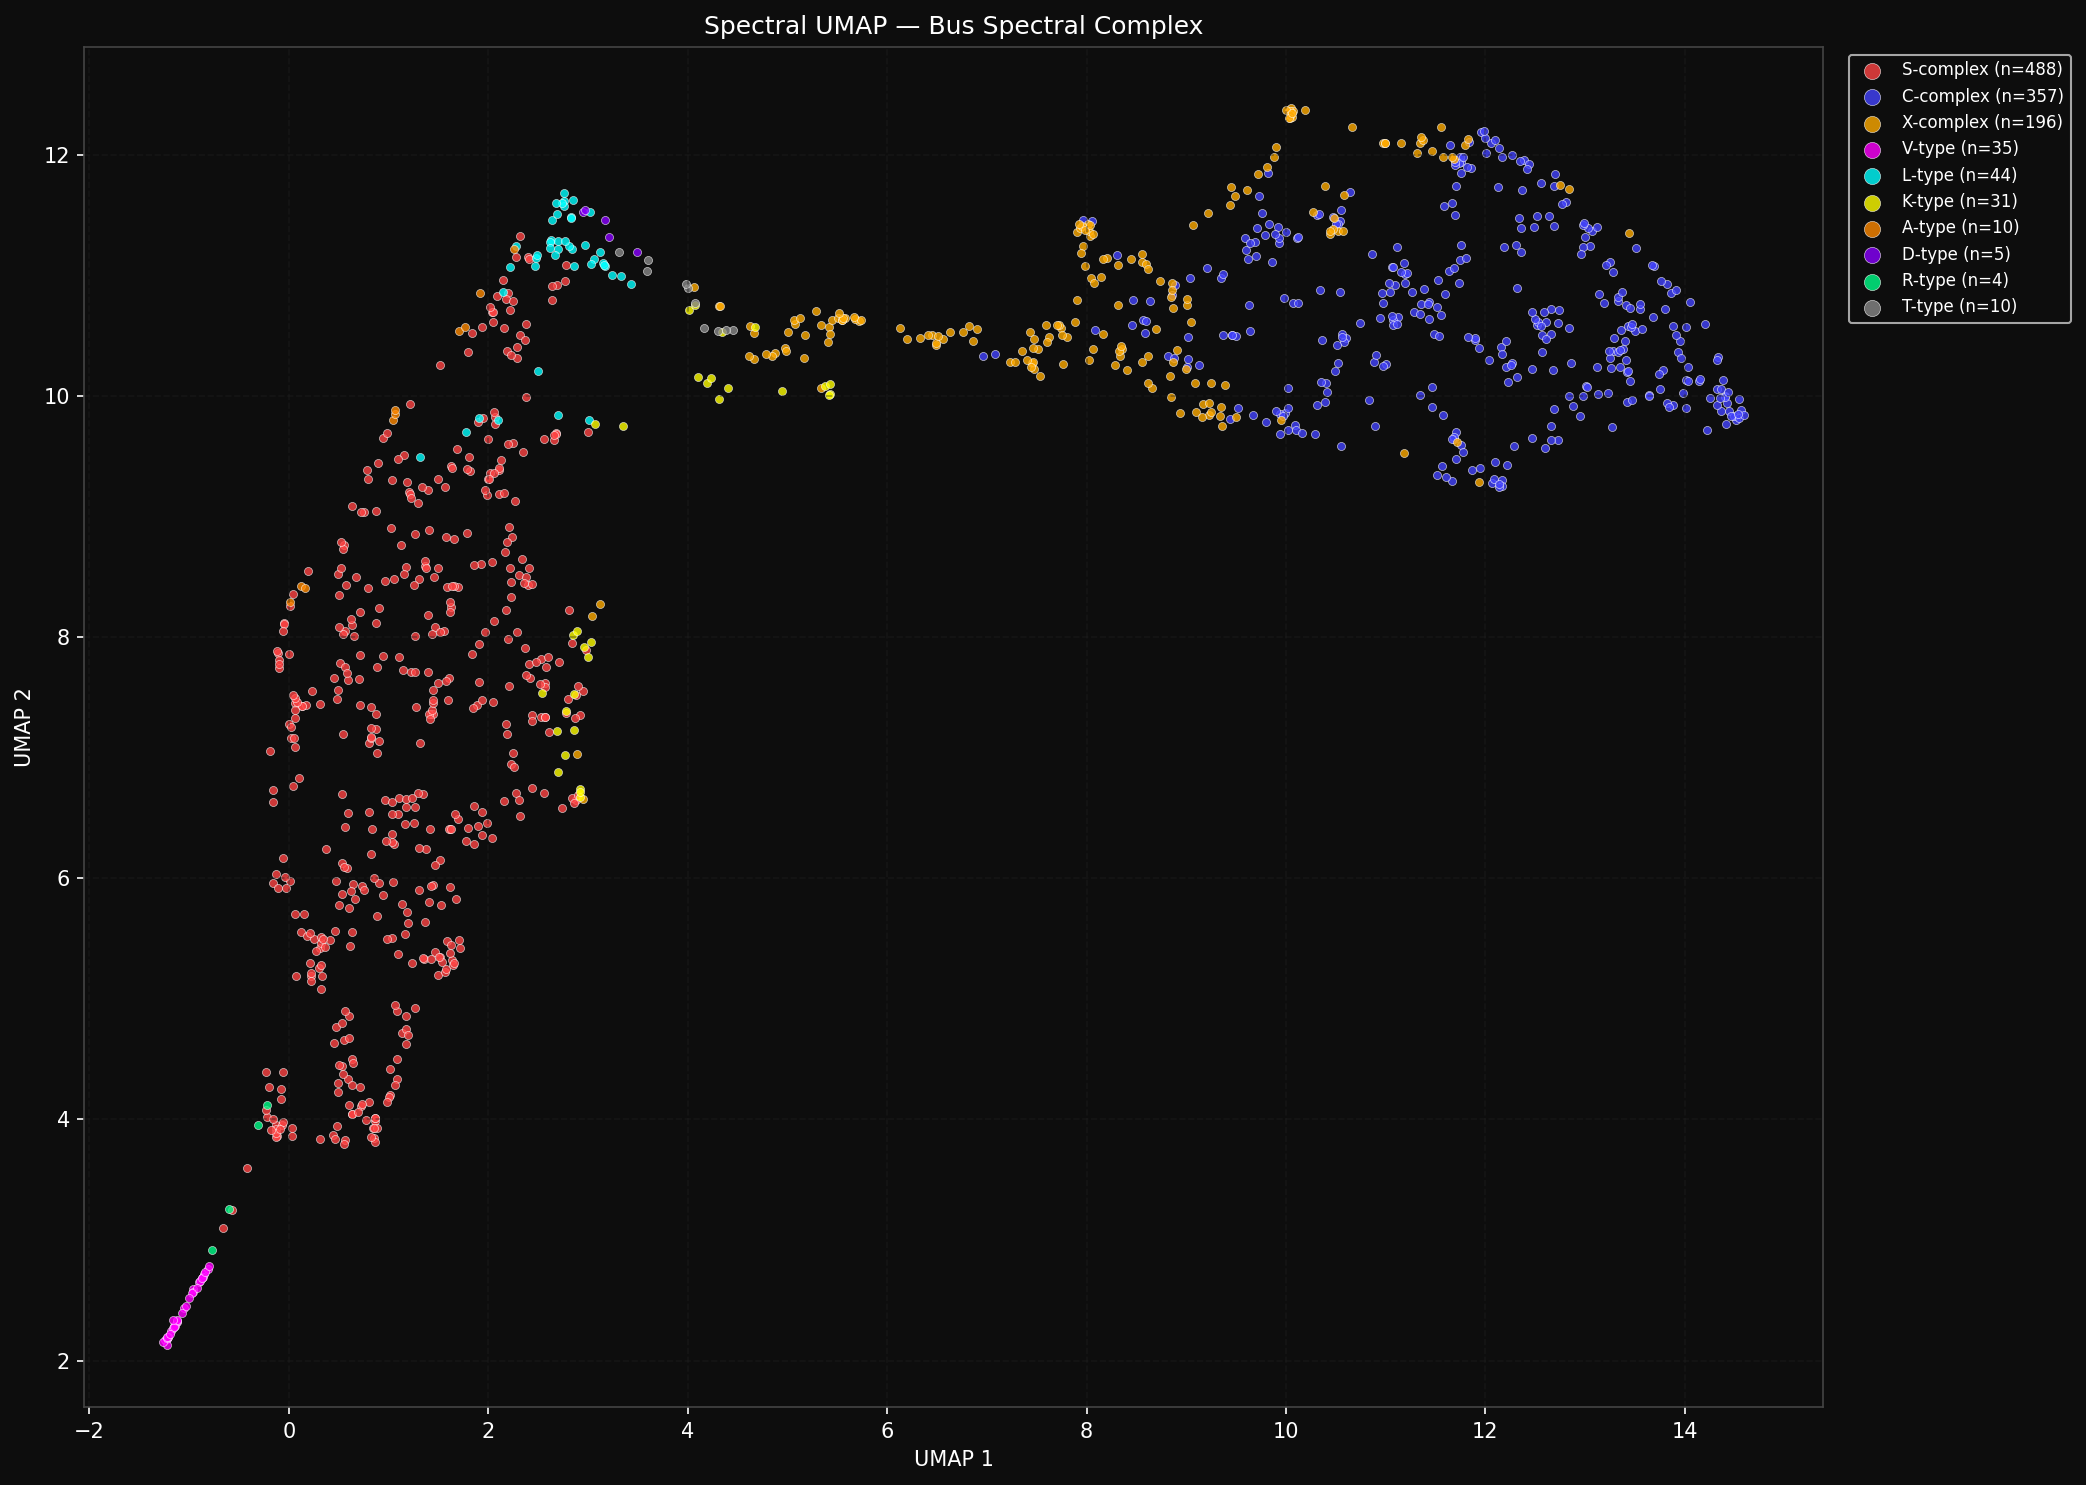

In [9]:
emb_spec = embeddings['Spectral']

fig, ax = plt.subplots(figsize=(14, 10))

for complex_type, color in COMPLEX_COLORS.items():
    mask = unified_df['Spectral_Complex'] == complex_type
    if mask.sum() == 0:
        continue
    ax.scatter(
        emb_spec[mask, 0], emb_spec[mask, 1],
        s=15, c=color, alpha=0.8,
        linewidths=0.3, edgecolors='white',
        label=f'{complex_type} (n={mask.sum()})'
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Spectral UMAP — Bus Spectral Complex')
ax.legend(fontsize=8, markerscale=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_umap_spectral_complex.png'),
#             dpi=200, bbox_inches='tight', bbox_extra_artists=[])
plt.show()

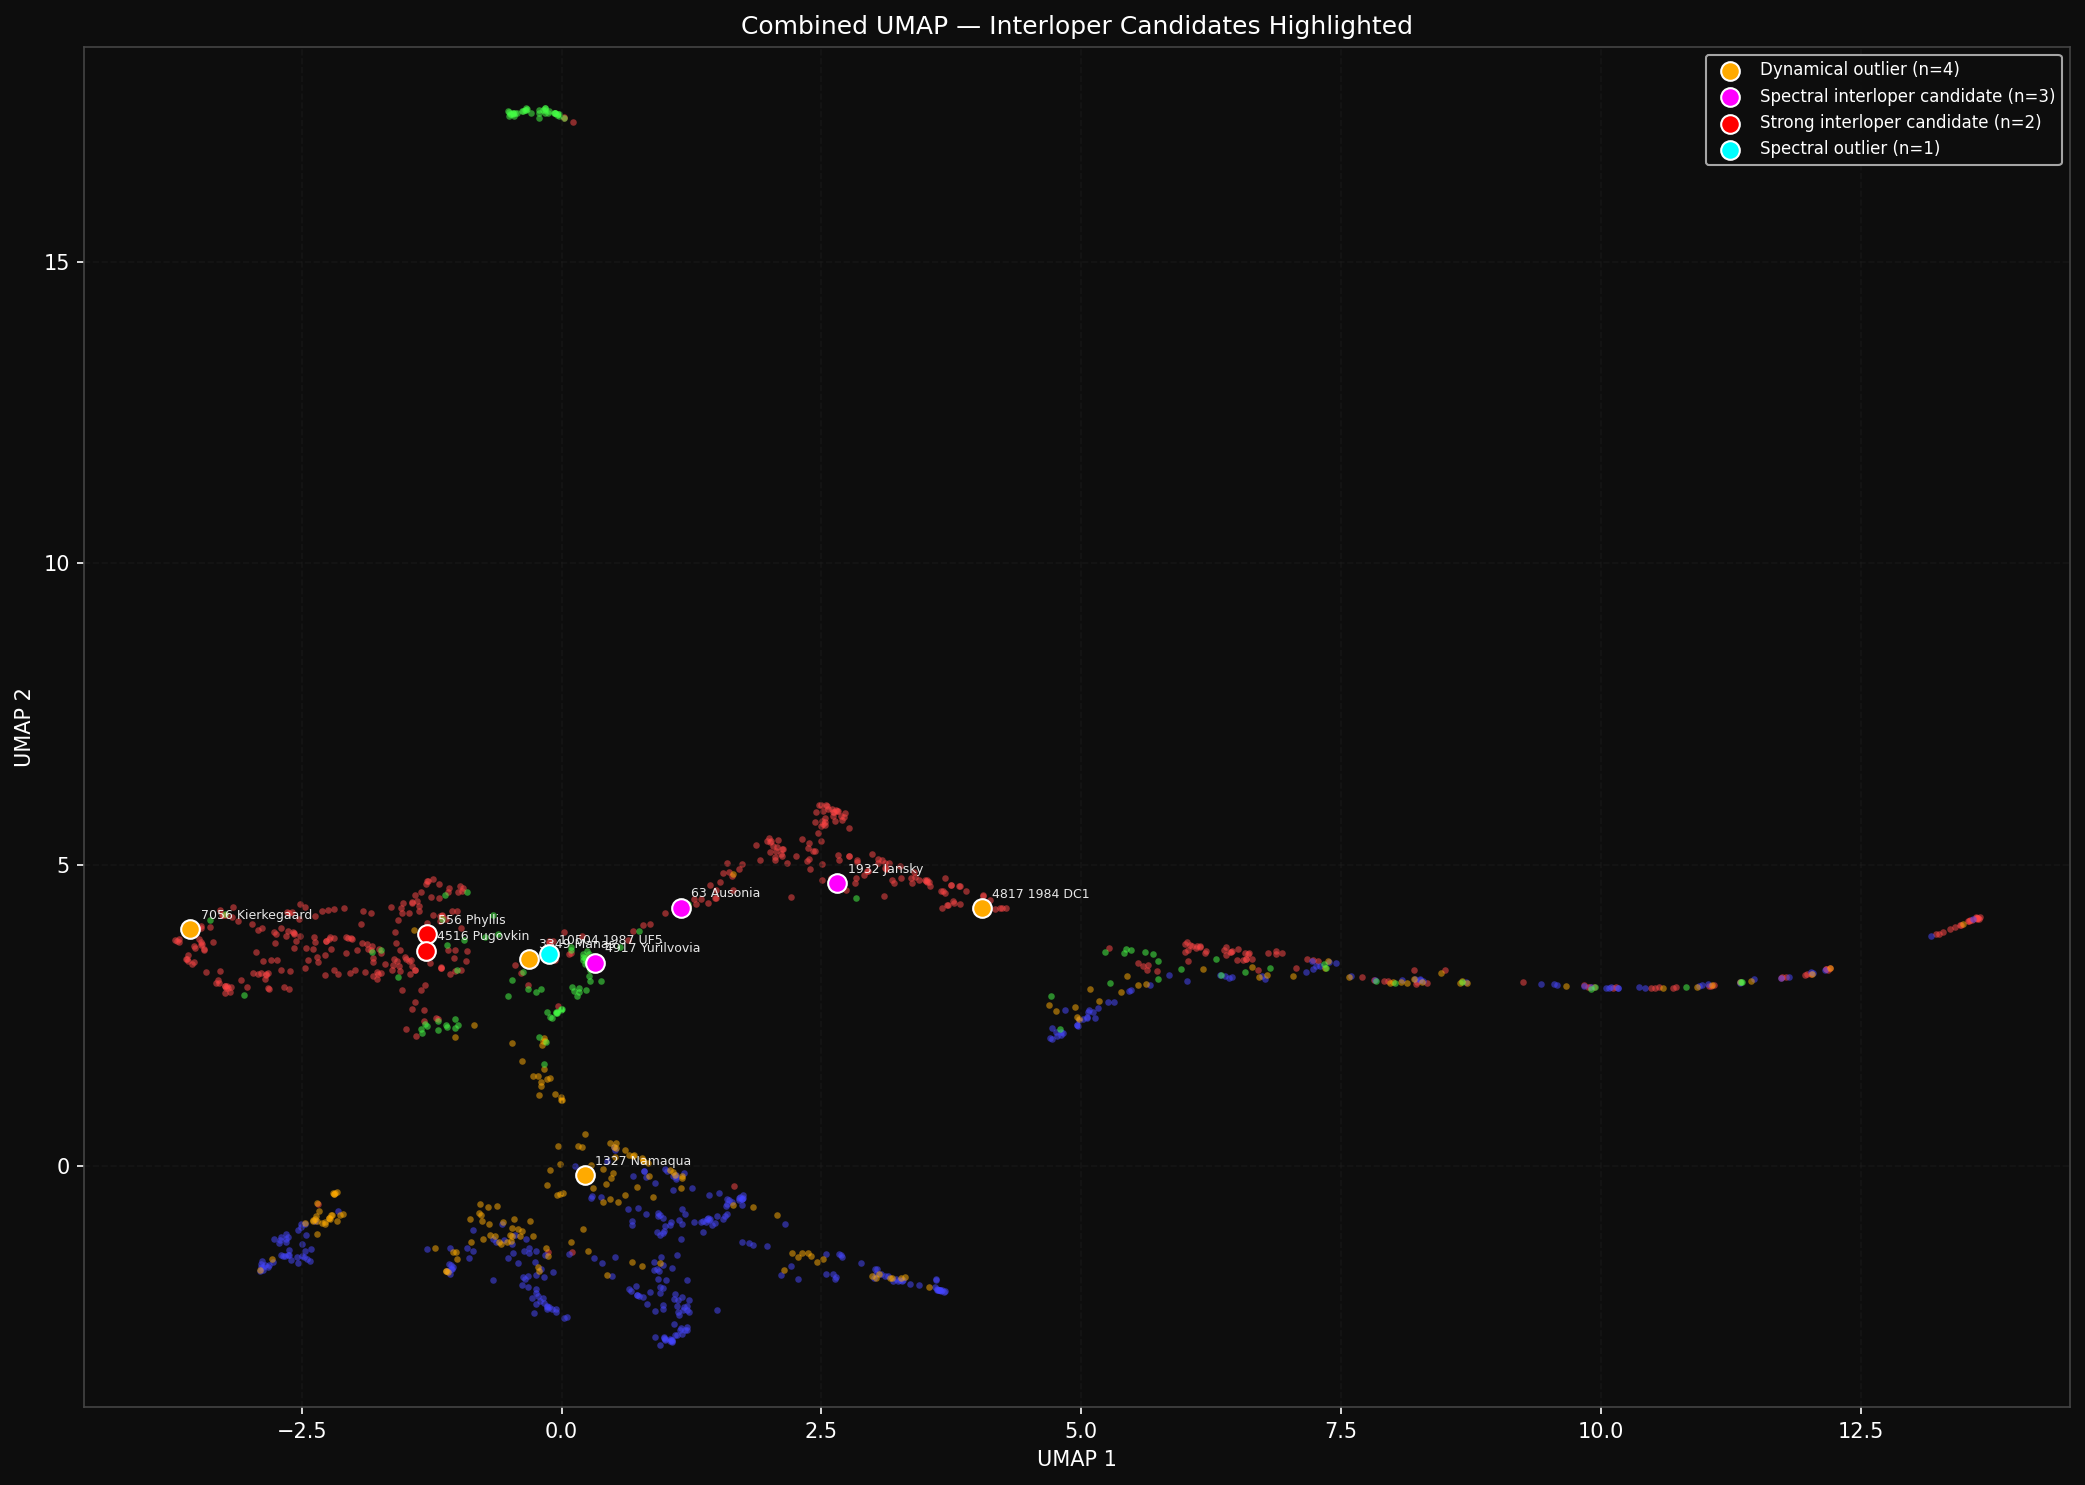

In [10]:
interloper_df = pd.read_pickle(
    os.path.join(results_path, '04_interloper_results.pkl')
)

emb = embeddings['Combined']

anomaly_colors = {
    'Nominal member'              : None,
    'Dynamical outlier'           : '#ffaa00',
    'Spectral interloper candidate': '#ff00ff',
    'Strong interloper candidate' : '#ff0000',
    'Spectral outlier'            : '#00ffff',
}

fig, ax = plt.subplots(figsize=(14, 10))

# Background — all asteroids in grey
ax.scatter(emb[:, 0], emb[:, 1],
           s=8, c='#222222', alpha=0.4, linewidths=0)

# Taxonomy layer
for group in groups:
    mask = unified_df['Main Group'] == group
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=10, c=TAX_COLORS[group], alpha=0.5,
               linewidths=0)

# Overlay interlopers
for anomaly_class, color in anomaly_colors.items():
    if color is None:
        continue
    inter_mask = interloper_df['anomaly_class'] == anomaly_class
    if inter_mask.sum() == 0:
        continue
    inter_ids = interloper_df[inter_mask]['Asteroid_id'].values
    emb_mask  = unified_df['Asteroid_id'].isin(inter_ids).values

    ax.scatter(emb[emb_mask, 0], emb[emb_mask, 1],
               s=80, c=color, alpha=1.0,
               linewidths=1.0, edgecolors='white',
               label=f'{anomaly_class} (n={inter_mask.sum()})',
               zorder=5)

    # Label names
    for aid in inter_ids:
        idx  = unified_df[unified_df['Asteroid_id'] == aid].index
        if len(idx) == 0:
            continue
        idx  = idx[0]
        name = unified_df.loc[idx, 'Name']
        ax.annotate(name, (emb[idx, 0], emb[idx, 1]),
                    fontsize=6, color='white', alpha=0.9,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Combined UMAP — Interloper Candidates Highlighted')
ax.legend(fontsize=8, markerscale=1)
ax.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_umap_interlopers.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

In [11]:
emb = embeddings['Combined']

hdb = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_method='eom',
    core_dist_n_jobs=-1
)

cluster_labels = hdb.fit_predict(emb)
unified_df['umap_cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()

print(f"HDBSCAN on Combined UMAP embedding:")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise} ({100*n_noise/len(unified_df):.1f}%)")

# Taxonomy composition per cluster
print(f"\nCluster taxonomy composition:")
for cid in sorted(set(cluster_labels)):
    mask    = cluster_labels == cid
    cluster = unified_df[mask]
    dominant = cluster['Main Group'].value_counts().index[0]
    purity   = cluster['Main Group'].value_counts().iloc[0] / mask.sum()
    label    = f"Cluster {cid}" if cid >= 0 else "Noise"
    print(f"  {label:<12} n={mask.sum():>4} | "
          f"dominant={dominant} ({100*purity:.0f}%) | "
          f"belt_zone a_p={cluster['a_p'].mean():.2f} AU")

HDBSCAN on Combined UMAP embedding:
  Clusters found : 14
  Noise points   : 32 (2.7%)

Cluster taxonomy composition:
  Noise        n=  32 | dominant=X (50%) | belt_zone a_p=2.77 AU
  Cluster 0    n=  40 | dominant=Other (92%) | belt_zone a_p=2.37 AU
  Cluster 1    n=  22 | dominant=S (86%) | belt_zone a_p=2.40 AU
  Cluster 2    n= 152 | dominant=S (35%) | belt_zone a_p=2.63 AU
  Cluster 3    n=  60 | dominant=S (40%) | belt_zone a_p=2.62 AU
  Cluster 4    n=  69 | dominant=C (59%) | belt_zone a_p=2.37 AU
  Cluster 5    n= 106 | dominant=C (59%) | belt_zone a_p=2.70 AU
  Cluster 6    n=  21 | dominant=X (86%) | belt_zone a_p=2.77 AU
  Cluster 7    n= 247 | dominant=S (88%) | belt_zone a_p=2.75 AU
  Cluster 8    n=  58 | dominant=C (72%) | belt_zone a_p=3.11 AU
  Cluster 9    n=  62 | dominant=Other (69%) | belt_zone a_p=2.75 AU
  Cluster 10   n= 150 | dominant=S (96%) | belt_zone a_p=2.28 AU
  Cluster 11   n=  61 | dominant=C (97%) | belt_zone a_p=2.76 AU
  Cluster 12   n=  46 | domin

/tmp/ipykernel_7816/2421750549.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap            = plt.cm.get_cmap('turbo', len(unique_clusters))


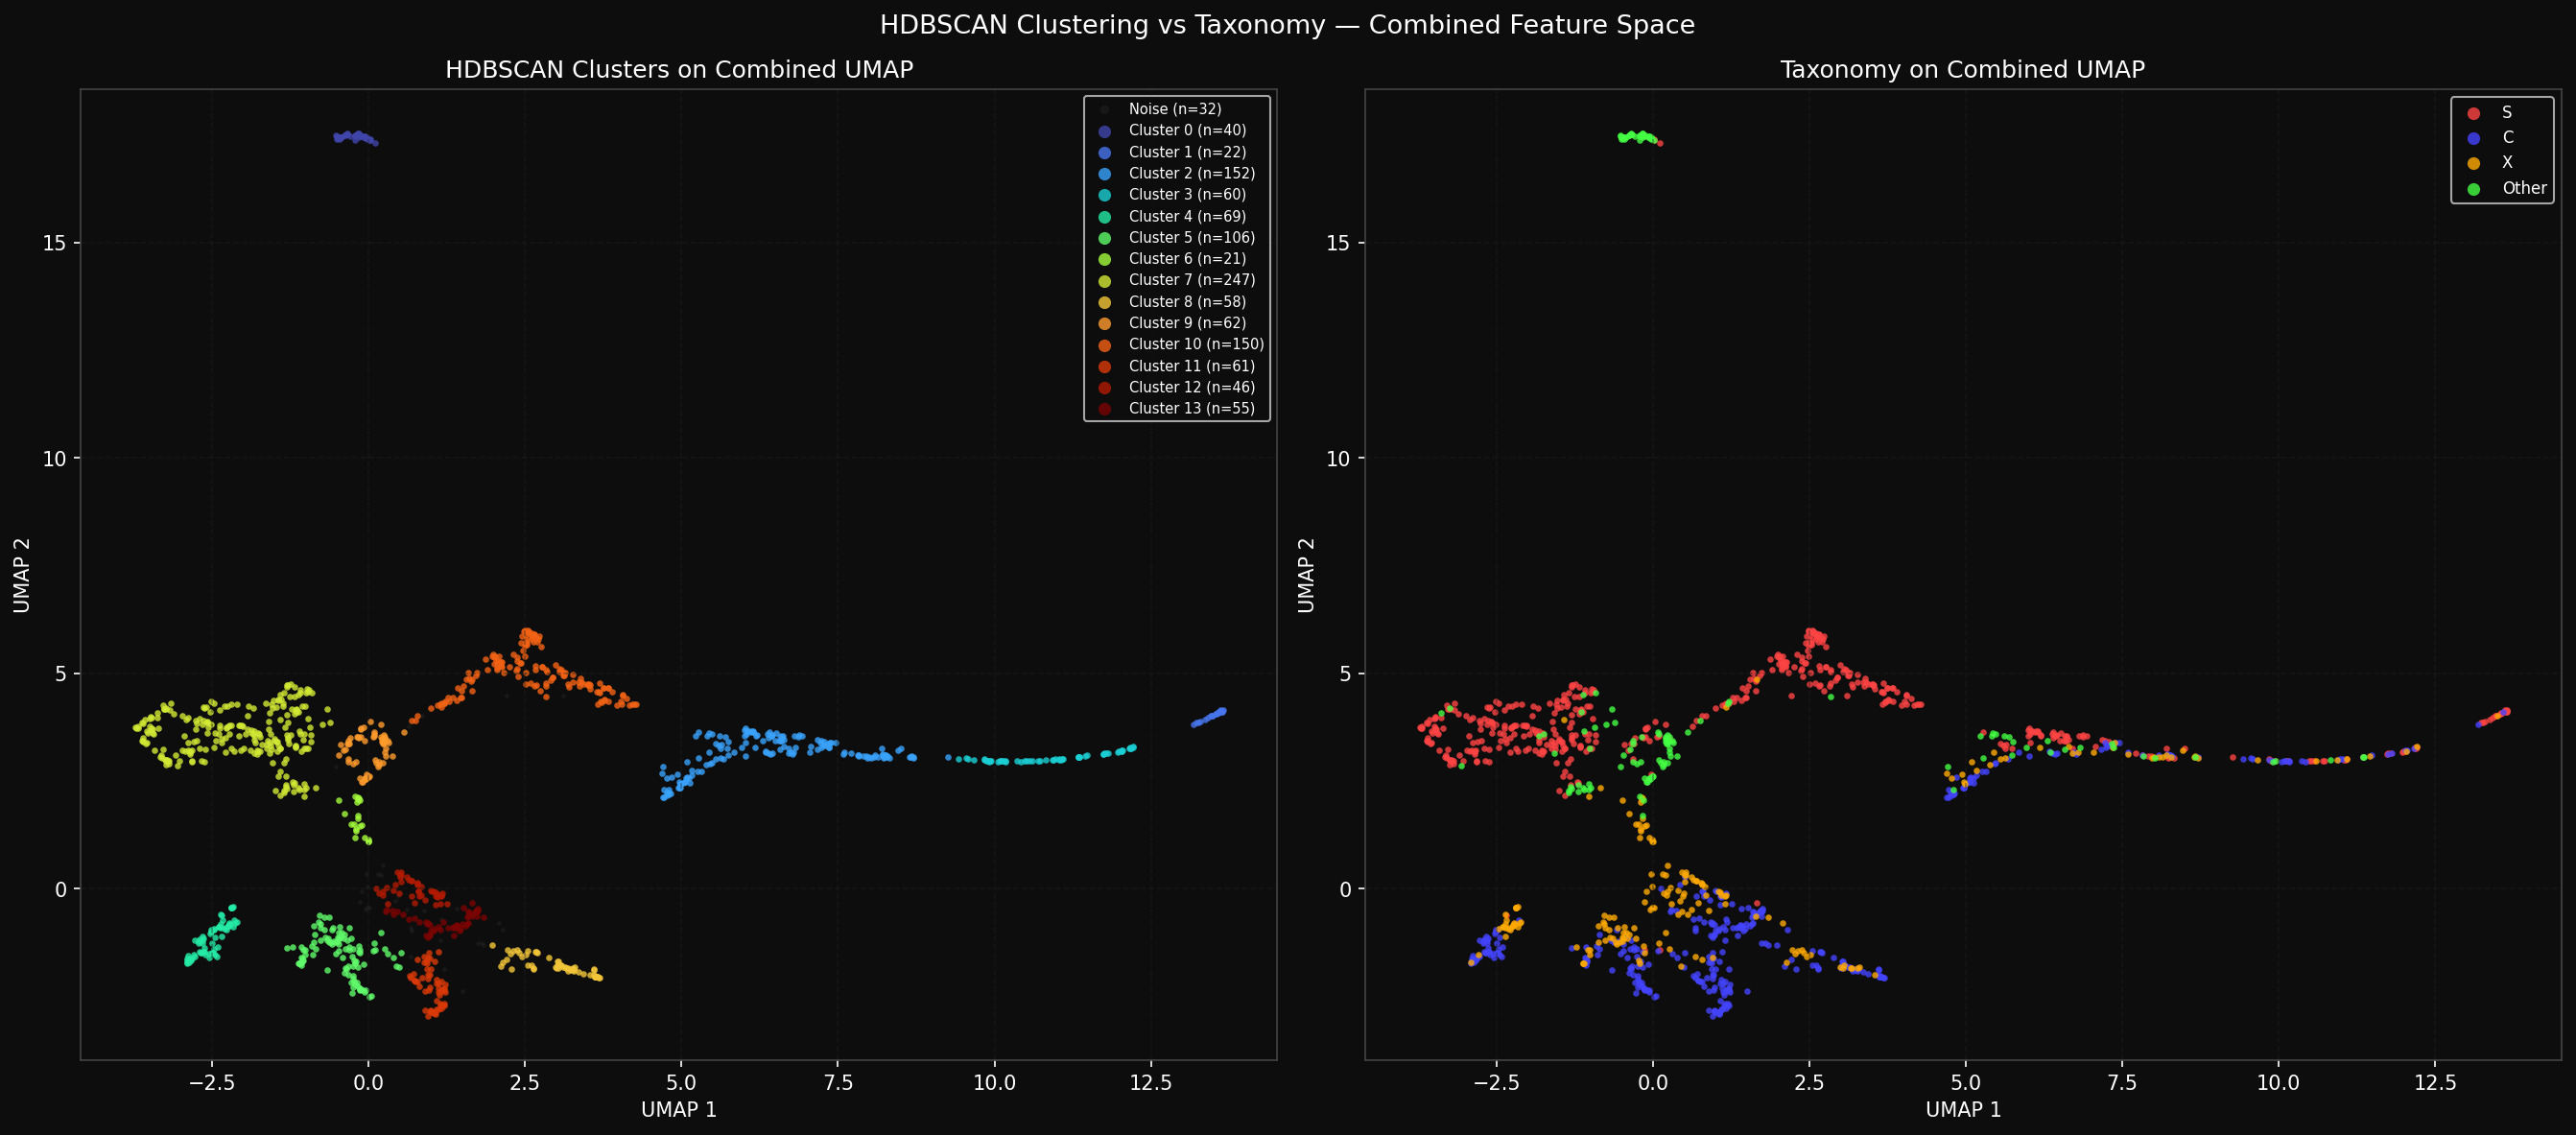

In [12]:
emb = embeddings['Combined']
unique_clusters = sorted(set(cluster_labels))
cmap            = plt.cm.get_cmap('turbo', len(unique_clusters))
cluster_colors  = {c: cmap(i) for i, c in enumerate(unique_clusters)}
cluster_colors[-1] = (0.2, 0.2, 0.2, 0.3)   # noise in dark grey

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left — colored by HDBSCAN cluster
ax = axes[0]
for cid in unique_clusters:
    mask = cluster_labels == cid
    label = f'Cluster {cid} (n={mask.sum()})' if cid >= 0 else f'Noise (n={mask.sum()})'
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=10 if cid >= 0 else 5,
               c=[cluster_colors[cid]], alpha=0.8 if cid >= 0 else 0.3,
               linewidths=0, label=label)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('HDBSCAN Clusters on Combined UMAP')
ax.legend(fontsize=7, markerscale=2)
ax.grid(True)

# Right — colored by taxonomy for comparison
ax = axes[1]
for group in groups:
    mask = unified_df['Main Group'] == group
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=10, c=TAX_COLORS[group], alpha=0.8,
               linewidths=0, label=group)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Taxonomy on Combined UMAP')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

plt.suptitle('HDBSCAN Clustering vs Taxonomy — Combined Feature Space',
             fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_umap_hdbscan.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

Computing t-SNE on combined features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1181 samples in 0.000s...
[t-SNE] Computed neighbors for 1181 samples in 0.044s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1181
[t-SNE] Computed conditional probabilities for sample 1181 / 1181
[t-SNE] Mean sigma: 0.867752
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.204948
[t-SNE] KL divergence after 1000 iterations: 0.747780


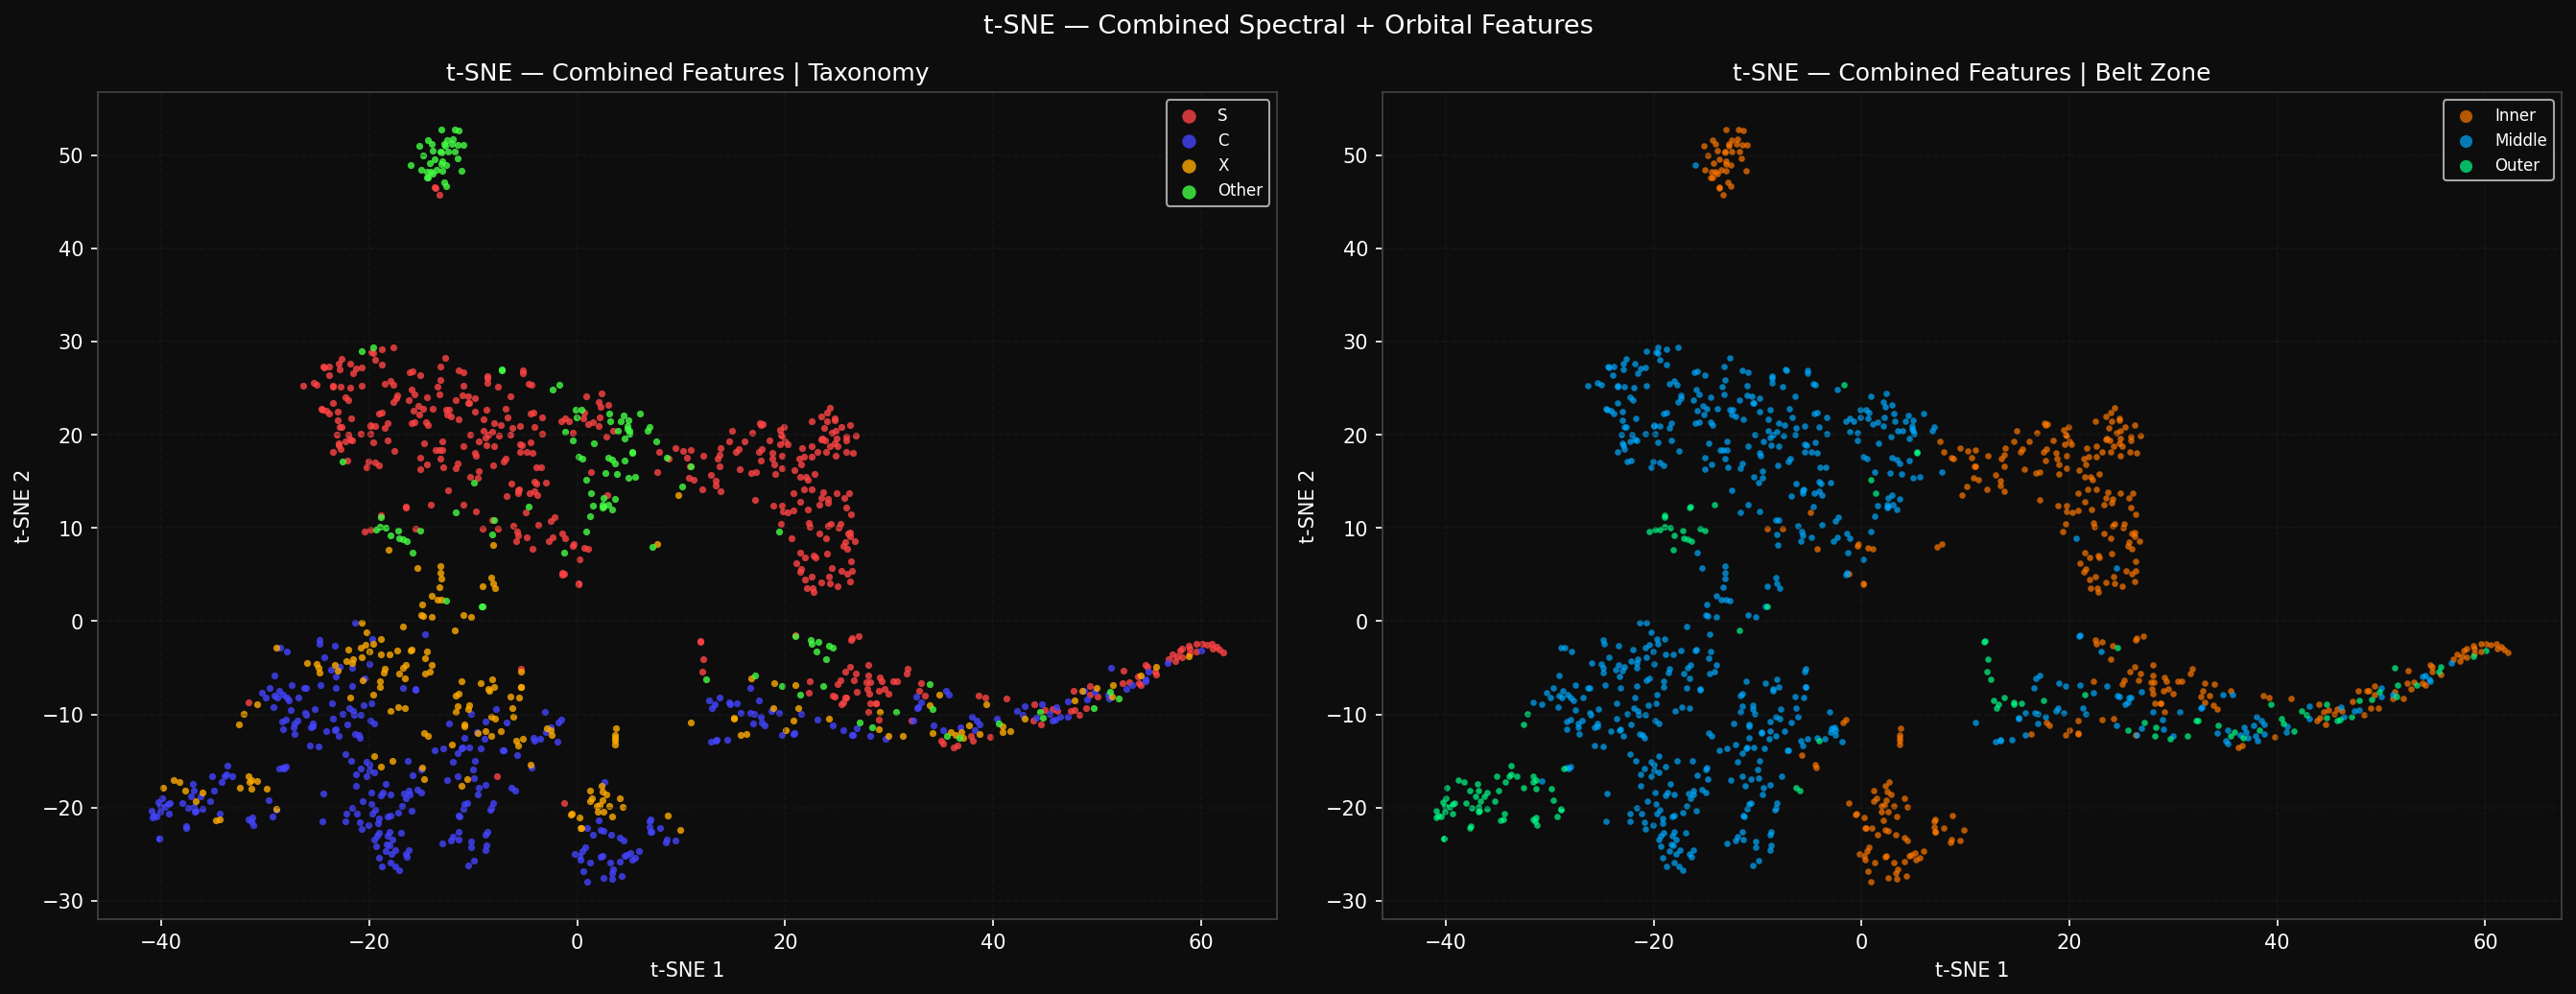

In [14]:
from sklearn.manifold import TSNE

print("Computing t-SNE on combined features...")
X_comb  = unified_df[COMBINED_FEATURES].astype(float).values
scaler  = RobustScaler()
X_comb_s = scaler.fit_transform(X_comb)

tsne = TSNE(n_components=2, perplexity=30,
            random_state=42, max_iter=1000, verbose=1)
emb_tsne = tsne.fit_transform(X_comb_s)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE colored by taxonomy
ax = axes[0]
for group in groups:
    mask = unified_df['Main Group'] == group
    ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
               s=12, c=TAX_COLORS[group], alpha=0.8,
               linewidths=0, label=group)
ax.set_title('t-SNE — Combined Features | Taxonomy')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

# t-SNE colored by belt zone
ax = axes[1]
for zone, (a_min, a_max), color in [
    ('Inner',  (2.0,  2.5),  '#ff7700'),
    ('Middle', (2.5,  2.95), '#00aaff'),
    ('Outer',  (2.95, 3.5),  '#00ff88'),
]:
    mask = (unified_df['a_p'] >= a_min) & (unified_df['a_p'] < a_max)
    ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
               s=10, c=color, alpha=0.7,
               linewidths=0, label=f'{zone}')
ax.set_title('t-SNE — Combined Features | Belt Zone')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True)

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE — Combined Spectral + Orbital Features', fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_tsne_combined.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

le_tax = LabelEncoder()
y_tax  = le_tax.fit_transform(unified_df['Main Group'].values)

# Only evaluate on non-noise points
non_noise = cluster_labels != -1
if non_noise.sum() > 0:
    ari = adjusted_rand_score(y_tax[non_noise], cluster_labels[non_noise])
    nmi = normalized_mutual_info_score(y_tax[non_noise], cluster_labels[non_noise])
    print(f"HDBSCAN vs Taxonomy alignment (non-noise points):")
    print(f"  ARI : {ari:.4f}  [0=random, 1=perfect]")
    print(f"  NMI : {nmi:.4f}  [0=random, 1=perfect]")

# Belt zone alignment
le_zone   = LabelEncoder()
zone_labels = pd.cut(unified_df['a_p'],
                     bins=[2.0, 2.5, 2.95, 3.5],
                     labels=['Inner', 'Middle', 'Outer'])
y_zone    = le_zone.fit_transform(zone_labels.fillna('Inner'))

if non_noise.sum() > 0:
    ari_zone = adjusted_rand_score(y_zone[non_noise], cluster_labels[non_noise])
    nmi_zone = normalized_mutual_info_score(y_zone[non_noise], cluster_labels[non_noise])
    print(f"\nHDBSCAN vs Belt Zone alignment:")
    print(f"  ARI : {ari_zone:.4f}")
    print(f"  NMI : {nmi_zone:.4f}")

print(f"\nConclusion:")
if ari > ari_zone:
    print("  Clusters align more with TAXONOMY than belt zone")
    print("  → Composition drives structure more than orbital location")
elif ari_zone > ari:
    print("  Clusters align more with BELT ZONE than taxonomy")
    print("  → Orbital dynamics drives structure more than composition")
else:
    print("  Clusters align equally with taxonomy and belt zone")

HDBSCAN vs Taxonomy alignment (non-noise points):
  ARI : 0.2297  [0=random, 1=perfect]
  NMI : 0.3618  [0=random, 1=perfect]

HDBSCAN vs Belt Zone alignment:
  ARI : 0.1619
  NMI : 0.3371

Conclusion:
  Clusters align more with TAXONOMY than belt zone
  → Composition drives structure more than orbital location


In [ ]:
# # Add t-SNE coordinates
# unified_df['tsne_x'] = emb_tsne[:, 0]
# unified_df['tsne_y'] = emb_tsne[:, 1]

# unified_df.to_pickle(os.path.join(results_path, 'unified_df.pkl'))

# umap_results = {
#     'embeddings'     : embeddings,
#     'cluster_labels' : cluster_labels,
#     'n_clusters'     : n_clusters,
#     'ari_taxonomy'   : ari,
#     'nmi_taxonomy'   : nmi,
#     'ari_zone'       : ari_zone,
#     'nmi_zone'       : nmi_zone,
# }

# with open(os.path.join(results_path, '06_umap_results.pkl'), 'wb') as f:
#     pickle.dump(umap_results, f)

# print("Saved → data/results/06_umap_results.pkl")
# print("Saved → unified_df.pkl (with UMAP + t-SNE coordinates)")